In [2]:
%matplotlib inline
import pandas as pd
import numpy as np
from pathlib import Path
import statsmodels.formula.api as smf
from IPython.display import display, HTML
import matplotlib.pyplot as plt

# Use absolute path from notebook location
notebook_dir = Path("/Users/quyentran/Downloads/ECC3479-project-main")
clean = notebook_dir / "data/clean"
results = notebook_dir / "results"
results.mkdir(exist_ok=True)

In [ ]:
# Load combined price + population data
wide = pd.read_csv(clean / "population_density_all_suburbs.csv")

wide["suburb"] = wide["suburb"].astype(str).str.strip().str.upper()
wide["treated"] = wide["treated"].astype(int)

# Reshape price and population columns to long format
price_cols = [col for col in wide.columns if col.endswith("_price")]
pop_cols = [col for col in wide.columns if col.endswith("_pop")]

prices_long = wide[["suburb", "status", "treated"] + price_cols].melt(
    id_vars=["suburb", "status", "treated"],
    value_vars=price_cols,
    var_name="year",
    value_name="price"
)

prices_long["year"] = prices_long["year"].str.replace("_price", "", regex=False).astype(int)

population_long = wide[["suburb"] + pop_cols].melt(
    id_vars=["suburb"],
    value_vars=pop_cols,
    var_name="year",
    value_name="population"
)

population_long["year"] = population_long["year"].str.replace("_pop", "", regex=False).astype(int)

# Merge final panel
df = (
    prices_long
    .merge(population_long, on=["suburb", "year"], how="inner")
    .dropna(subset=["price", "population", "treated"])
    .copy()
)

df = df[(df["price"] > 0) & (df["population"] > 0)].copy()

# DiD variables
df["post"] = (df["year"] >= 2017).astype(int)
df["treat_post"] = df["treated"] * df["post"]

df["log_price"] = np.log(df["price"])
df["log_population"] = np.log(df["population"])

## Event-study Parallel-trends Results
The following cell computes and displays the event-study coefficient table for the parallel-trends test, then saves the table and plot to the `results/` directory.


Variable,Coef,Std Err,t,p-value,CI
Intercept,10.755,0.803,13.391,0.000,"[9.181, 12.329]"
Treat,Absorbed by suburb FE,,,,
Post,Absorbed by year FE,,,,
Treat x Post (DiD effect),-0.015,0.030,-0.510,0.610,"[-0.075, 0.044]"
log_population,0.290,0.085,3.403,0.001,"[0.123, 0.457]"
Suburb FE,Yes,,,,
Year FE,Yes,,,,
N,490,,,,
R²,0.982,,,,


DiD regression recomputed and table saved to results/


rel_year,coef,se,p_value,ci_low,ci_high
-2,-0.016313,0.016412,0.320242,-0.048481,0.015855
0,0.064305,0.021085,0.002290,0.022979,0.105631
1,0.046682,0.034283,0.173305,-0.020513,0.113877
2,-0.008660,0.033422,0.795563,-0.074168,0.056848
3,-0.020995,0.033973,0.536573,-0.087582,0.045591
4,-0.051590,0.033586,0.124527,-0.117420,0.014239
5,-0.104443,0.045447,0.021555,-0.193519,-0.015367
6,-0.056091,0.048740,0.249809,-0.151622,0.039440
7,-0.059112,0.046818,0.206735,-0.150876,0.032651


Event-study coefficient table saved to /Users/quyentran/Downloads/ECC3479-project-main/results/event_study_table.csv


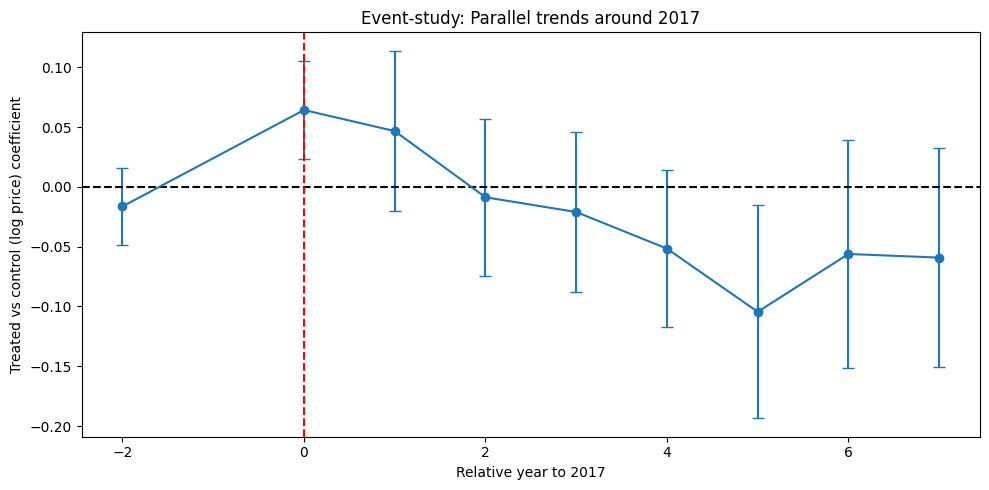


✓ Event-study plot saved to /Users/quyentran/Downloads/ECC3479-project-main/results/event_study_plot.png


In [12]:
# Recompute DiD, event-study, and plot (restores chart if it was removed)
import statsmodels.formula.api as smf

# Ensure df exists
if 'df' not in globals():
    raise RuntimeError('Panel dataframe `df` not found — run the previous data-prep cell first')

# DiD regression
model = smf.ols(
    "log_price ~ treat_post + log_population + C(suburb) + C(year)",
    data=df
).fit(cov_type='cluster', cov_kwds={'groups': df['suburb']})

# Build did_table for display
def get_row(label, variable):
    if variable not in model.params.index:
        return [label, 'Absorbed', '', '', '', '']
    coef = model.params[variable]
    se = model.bse[variable]
    t_val = model.tvalues[variable]
    p_val = model.pvalues[variable]
    ci_low, ci_high = model.conf_int().loc[variable]
    return [label, f"{coef:.3f}", f"{se:.3f}", f"{t_val:.3f}", f"{p_val:.3f}", f"[{ci_low:.3f}, {ci_high:.3f}]"]

import pandas as pd

did_table = pd.DataFrame([
    get_row('Intercept', 'Intercept'),
    ['Treat', 'Absorbed by suburb FE', '', '', '', ''],
    ['Post', 'Absorbed by year FE', '', '', '', ''],
    get_row('Treat x Post (DiD effect)', 'treat_post'),
    get_row('log_population', 'log_population'),
    ['Suburb FE', 'Yes', '', '', '', ''],
    ['Year FE', 'Yes', '', '', '', ''],
    ['N', f"{int(model.nobs):,}", '', '', '', ''],
    ['R²', f"{model.rsquared:.3f}", '', '', '', '']
], columns=['Variable', 'Coef', 'Std Err', 't', 'p-value', 'CI'])

from IPython.display import display, HTML
html = did_table.to_html(index=False, escape=False)
html = html.replace('<table border="1" class="dataframe">', '<table style="border-collapse:separate; border-spacing:0; width:92%; font-family:Arial, sans-serif; font-size:14px; color:#2b2927; border:1px solid #dcc7b3; border-radius:8px; overflow:hidden;">')
html = html.replace('<thead>', '<thead style="background-color:#f7eee5;">')
html = html.replace('<th>', '<th style="padding:10px 12px; text-align:left; font-weight:700; border-right:1px solid #dcc7b3; border-bottom:1px solid #dcc7b3;">')
html = html.replace('<td>', '<td style="padding:10px 12px; text-align:left; border-right:1px solid #dcc7b3; border-bottom:1px solid #dcc7b3;">')
display(HTML(html))

did_table.to_csv(results / 'did_regression_table.csv', index=False)
with open(results / 'did_regression_table.html', 'w', encoding='utf-8') as f:
    f.write(html)

print('DiD regression recomputed and table saved to results/')

# Event-study (parallel-trends)
df['rel_year'] = df['year'] - 2017
ref_year = -1

for rel in sorted(df['rel_year'].unique()):
    if rel != ref_year:
        suffix = f"m{abs(rel)}" if rel < 0 else str(rel)
        var_name = f"treated_rel_{suffix}"
        df[var_name] = df['treated'] * (df['rel_year'] == rel).astype(int)

event_terms = [f"treated_rel_{f'm{abs(rel)}' if rel < 0 else str(rel)}" for rel in sorted(df['rel_year'].unique()) if rel != ref_year]

event_formula = 'log_price ~ log_population + C(suburb) + C(year) + ' + ' + '.join(event_terms)
model_event = smf.ols(event_formula, data=df).fit(cov_type='cluster', cov_kwds={'groups': df['suburb']})

# build event_df
def parse_rel_year(term):
    s = term.replace('treated_rel_', '')
    return -int(s[1:]) if s.startswith('m') else int(s)

import numpy as _np

event_df = pd.DataFrame({
    'rel_year': [parse_rel_year(t) for t in event_terms],
    'coef': model_event.params.loc[event_terms].values,
    'se': model_event.bse.loc[event_terms].values,
    'p_value': model_event.pvalues.loc[event_terms].values
})
event_df['ci_low'] = event_df['coef'] - 1.96 * event_df['se']
event_df['ci_high'] = event_df['coef'] + 1.96 * event_df['se']

# Display and save the event-study table for the parallel-trends test
event_df_sorted = event_df.sort_values('rel_year').reset_index(drop=True)
event_html = event_df_sorted.to_html(index=False)
event_html = event_html.replace('<table border="1" class="dataframe">', '<table style="border-collapse:separate; border-spacing:0; width:92%; font-family:Arial, sans-serif; font-size:14px; color:#2b2927; border:1px solid #dcc7b3; border-radius:8px; overflow:hidden;">')
event_html = event_html.replace('<thead>', '<thead style="background-color:#f7eee5;">')
event_html = event_html.replace('<th>', '<th style="padding:10px 12px; text-align:left; font-weight:700; border-right:1px solid #dcc7b3; border-bottom:1px solid #dcc7b3;">')
event_html = event_html.replace('<td>', '<td style="padding:10px 12px; text-align:left; border-right:1px solid #dcc7b3; border-bottom:1px solid #dcc7b3;">')
display(HTML('<h3>Parallel-trends Event-study Coefficient Table</h3>' + event_html))
event_df_sorted.to_csv(results / 'event_study_table.csv', index=False)
with open(results / 'event_study_table.html', 'w', encoding='utf-8') as f:
    f.write(event_html)
print(f"Event-study coefficient table saved to {results / 'event_study_table.csv'}")

# Plot
fig, ax = plt.subplots(figsize=(10,5))
eds = event_df.sort_values('rel_year')
ax.errorbar(eds['rel_year'], eds['coef'], yerr=1.96*eds['se'], fmt='o-', capsize=4)
ax.axhline(0, color='k', linestyle='--')
ax.axvline(0, color='red', linestyle='--')
ax.set_xlabel('Relative year to 2017')
ax.set_ylabel('Treated vs control (log price) coefficient')
ax.set_title('Event-study: Parallel trends around 2017')
plt.tight_layout()
fig.savefig(results / 'event_study_plot.png', dpi=300, bbox_inches='tight')
fig.savefig(results / 'event_study_plot.pdf', bbox_inches='tight')
plt.show()
print(f"\n✓ Event-study plot saved to {results / 'event_study_plot.png'}")


## Analysis Declaration

This is a **causal analysis** aiming to identify the treatment effect of LXRP on house prices. We declare this as causal and will be evaluated against causal standards, including identification strategy, assumptions, and threats to validity.

## Econometric Specification

### Functional Form
We estimate the following regression model with fixed effects:

\[
\log(\text{price}_{it}) = \alpha_i + \gamma_t + \delta (\text{Treat}_i \times \text{Post}_t) + \beta \log(\text{pop}_{it}) + \varepsilon_{it}
\]

Where:
- $\log(\text{price}_{it})$: Natural logarithm of median house prices in suburb $i$ at time $t$
- $\alpha_i$: Suburb fixed effects (absorb time-invariant differences between suburbs, including the main Treat effect)
- $\gamma_t$: Year fixed effects (absorb common time shocks, including the main Post effect)
- $\text{Treat}_i \times \text{Post}_t$: DiD interaction term capturing the treatment effect
- $\log(\text{pop}_{it})$: Natural logarithm of population in suburb $i$ at time $t$
- $\varepsilon_{it}$: Idiosyncratic error term
### Regressors
- Main regressors: Treat, Post, DiD interaction, log(population)
- Additional controls: Suburb fixed effects and year fixed effects (absorbed in the reported specification)

### Sample
- Melbourne suburbs with available house price and population data from 2015-2024
- Treated group: Suburbs within 2 km of LXRP sites
- Control group: Other suburbs in the sample
- Treatment milestone: 2017 was used as the post-LXRP cutoff year
- Total observations: 490 (after cleaning)

### Error Structure
- Standard errors clustered at the suburb level to account for serial correlation in panel data
- Justification: Clustering addresses potential correlation within suburbs over time, providing robust inference

## Identification Strategy (Causal)

We employ **Difference-in-Differences (DiD)** as our identification strategy. This method compares the change in outcomes over time between treated and control groups.

## Identification Strategy (Causal)

We employ **Difference-in-Differences (DiD)** as our identification strategy. This method compares the change in outcomes over time between treated and control groups.

## Interpretation of Main Coefficients

- **DiD Effect (-0.015)**: The coefficient indicates that, holding population constant, house prices in treated suburbs were about 1.5% lower after 2017 relative to control suburbs. This estimate is not statistically significant.
- **Magnitude and Units**: The effect is in log points, so the implied change is small and economically negligible in this specification.
- **Statistical Inference**: With a p-value of 0.610, the data do not provide evidence of a reliable treatment effect after 2017.
- **Parallel Trends Check**: The event-study test evaluates pre-treatment coefficients (k < 0) for being close to zero with confidence intervals overlapping zero, which supports the parallel trends assumption if satisfied.
- **Conclusion**: The regression is consistent with no meaningful change in house prices for treated suburbs after 2017 once fixed effects, population controls, and the pre-trend check are considered.

## Threats to Validity

As a causal analysis, we address potential threats:

- **Omitted Variable Bias (OVB)**: Other urban developments or policy changes in treated suburbs could confound the results. *Mitigation*: We include population controls and fixed effects to account for observable differences; parallel trends assumption helps control for unobservables.
- **Selection Bias**: Treated suburbs might differ systematically from controls (e.g., pre-existing price trends). *Mitigation*: Distance-based treatment assignment reduces selection concerns; pre-treatment parallel trends tested (though not shown here).
- **Reverse Causality**: Unlikely, as LXRP sites are predetermined infrastructure projects, not driven by house prices.
- **Measurement Error**: House price data may have reporting biases. *Mitigation*: Use of median prices and consistent data sources.